In [81]:
import numpy as np
import time
import redshifts
import common as c
import copy
import healpy as hp
import estim
from estim import estimator
import importlib
import spectra
import matplotlib.pyplot as plt
from math import pi
import my_remote_spectra as rs
from classy import Class
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [82]:
def plot_cross_section(fft3dmap):
    fig, _ = plt.subplots(3, 1,figsize=(6*1,4.5*3))
    
    ax1 = plt.subplot(3,1,1)
    fig.colorbar(ax1.imshow(fft3dmap[0,:,:], origin='lower'), ax=ax1)
    ax1.set_xlabel('y')
    ax1.set_ylabel('z')

    ax2 = plt.subplot(3,1,2)
    # ax2.imshow(psi_i[0,:,:].T)
    fig.colorbar(ax2.imshow(fft3dmap[:,0,:].T, origin='lower'), ax=ax2)
    ax2.set_xlabel('x')
    ax2.set_ylabel('z')

    ax3 = plt.subplot(3,1,3)
    # ax3.imshow(psi_i[:,10,:])
    fig.colorbar(ax3.imshow(fft3dmap[:,:,0], origin='lower'), ax=ax3)
    ax3.set_xlabel('y')
    ax3.set_ylabel('x')

def RDF_recNoise(lmin, lmax, Cltaug, ClTT, Clgg):
    # all the input spectra should include noise
    ls = np.arange(lmax+1)
    ls = np.tile(ls[:, np.newaxis], (1, Cltaug.shape[-1]))
    
    return 1/np.sum((2*ls[lmin:,]+1)/(4*np.pi)*Cltaug[lmin:,]**2/(ClTT[lmin:,]*Clgg[lmin:,]), axis=0)

def RQF_E_recNoise(lmin, lmax, Cltaug, ClEE, Clgg):
    # all the input spectra should include noise
    ls = np.arange(lmax+1)
    ls = np.tile(ls[:, np.newaxis], (1, Cltaug.shape[-1]))
    
    return 1/np.sum(6/100*(2*ls[lmin:,]+1)/(4*np.pi)*Cltaug[lmin:,]**2/(ClEE[lmin:,]*Clgg[lmin:,]), axis=0)

In [83]:
import config as conf

In [84]:
data_lmax = 4000
lmax = 4000
ls = np.arange(lmax+1)

zb = redshifts.binning(conf_module = conf) 
estimator = estimator(data_lmax, conf)
beam = conf.beamArcmin_T*np.pi/180./60.
dT = conf.noiseTuKArcmin_T*np.pi/180./60./conf.T_CMB
TT_noise = estimator.CMB_noise(np.arange(estimator.data_lmax+1), beam, dT)
EE_noise = 2*TT_noise

Default lss = 'g' . Modify with set_lss method.
Default N_fine_modes = 10. Modify with set_Nfine method.


In [114]:
estimator.basic_conf_dir
zb.zbins_z

{'z_max': 5,
 'z_min': 0.4,
 'use_halomodel': False,
 'gasprofile': 'AGN',
 'halomassfunction': 'Tinker',
 'mdef': 'm200d',
 'log_kmax': 2,
 'log_kmin': -5,
 'k_res': 1000,
 'As': 2.2,
 'Omega_m': 0.31,
 'Omega_b': 0.049,
 'Omega_c': 0.261,
 'Omega_r_h2': 4.1500000000000006e-05,
 'mnu': 0.06,
 'h': 0.68,
 'H0': 68.0,
 'ns': 0.965,
 'ombh2': 0.022657600000000007,
 'omch2': 0.12068640000000003,
 'Omega_r': 9.236000000000002e-05,
 'Omega_K': 0.0,
 'w': -1.0,
 'wa': 0.0,
 'zdec': 1090,
 'adec': 0.0009165902841429881,
 'tau': 0.06,
 'T_CMB': 2725000.0,
 'fNL': 0.0,
 'delta_collapse': 1.686,
 'CIB_model': 'Websky'}

array([0.4       , 0.58808955, 0.80046341, 1.04406439, 1.32793712,
       1.66408188, 2.06874669, 2.56443214, 3.18309387, 3.97143445,
       5.        ])

In [86]:
params = {
    'A_s':conf.As*1e-9,
    'n_s': conf.ns,
    'h':conf.h,
    'omega_b':conf.ombh2,
    'omega_cdm':conf.omch2,
    'tau_reio':conf.tau,
    "output" : " tCl, pCl, lCl" ,
    "l_max_scalars" : data_lmax,
    "lensing": 'yes'
}

cosmo = Class()
cosmo.set(params)
cosmo.compute(level=['lensing'])
lensed_cls = cosmo.lensed_cl()
raw_cls = cosmo.raw_cl()

True

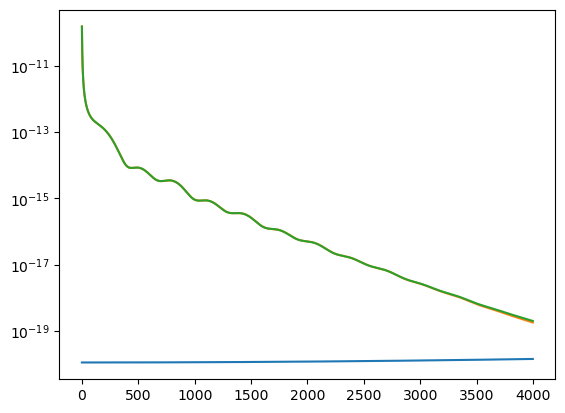

In [92]:
estimator.set_theory_Cls(add_ksz = False, add_ml=False)

plt.plot(TT_noise[2:, 0, 0])
plt.plot(lensed_cls['tt'][2:])
plt.plot(estimator.Cls['pCMB-pCMB'][2:, 0, 0])
plt.yscale('log')

In [93]:
conf_file = c.get_basic_conf(conf, exclude=False)
c.get_hash(conf_file)

'1d344a5660cbaed90fa4188bac23c2e4'

In [94]:
estimator.estim_dir

'estim/1d344a5660cbaed90fa4188bac23c2e4/T_freq=None/'

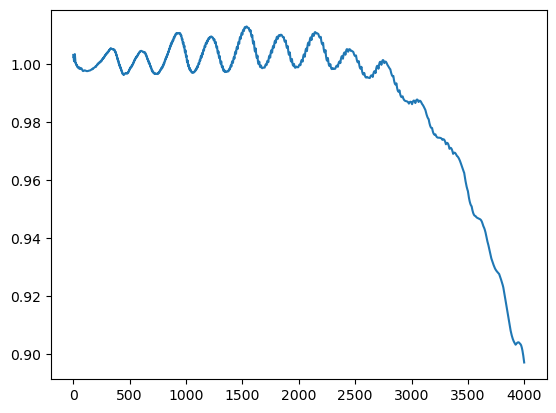

In [95]:
plt.plot(lensed_cls['tt'][2:data_lmax+1]/estimator.Cls['pCMB-pCMB'][2:, 0, 0])

In [143]:
Clgg = estimator.Cls['lss-lss'] # with shot noise (also maybe calibration noise)
Cltaudg = estimator.Cls['taud-lss']
Cltaug = Cltaudg*zb.deltachi
ClTT = estimator.Cls['T-T'] # with noise
ClEE = np.tile(lensed_cls['ee'][:, np.newaxis, np.newaxis], (1, ClTT.shape[-1]))
Clvrvr = estimator.Cls['vr-vr']

ClN_RDF = RDF_recNoise(2, lmax, Cltaug.diagonal(axis1=1, axis2=2), ClTT.diagonal(axis1=1, axis2=2), Clgg.diagonal(axis1=1, axis2=2))
ClN_RQF_E = RQF_E_recNoise(2, lmax, Cltaug.diagonal(axis1=1, axis2=2), ClEE.diagonal(axis1=1, axis2=2), Clgg.diagonal(axis1=1, axis2=2))

In [144]:
ClTT.shape
ClEE.shape

(4001, 1, 1)

(4001, 1, 1)

In [145]:
Clvrvr_ana_localDopp = rs.get_CLvv_localdopp()

Calculating Cl_vv...
Done bin 0
Done bin 1
Done bin 2
Done bin 3
Done bin 4
Done bin 5
Done bin 6
Done bin 7
Done bin 8
Done bin 9


In [103]:
Clvrvr_ana = rs.get_CLvv()
Clqeqe_ana = rs.get_CLqq()

Calculating Cl_vv...
Done bin 0
Done bin 1
Done bin 2
Done bin 3
Done bin 4
Done bin 5
Done bin 6
Done bin 7
Done bin 8
Done bin 9
Calculating Cl_qq...
Done bin 0
Done bin 1
Done bin 2
Done bin 3
Done bin 4
Done bin 5
Done bin 6
Done bin 7
Done bin 8
Done bin 9


In [146]:
Clqeqe_ana.shape
Clvrvr_ana.shape

(10, 100)

(10, 100)

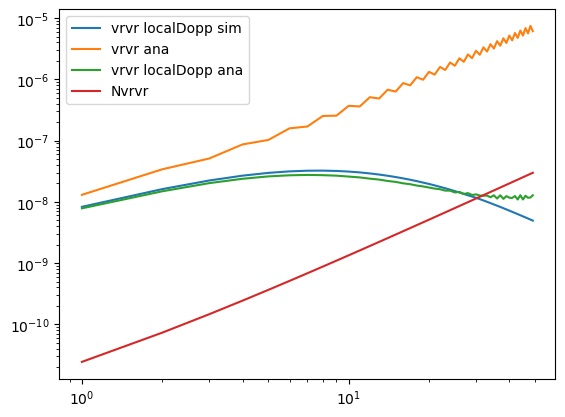

In [147]:
bin_num = 0
llow, lhigh = 1, 50

factor = (ls*(ls+1)/(2*pi))

# plt.plot(L, CLgg[:, bin_num, bin_num], label='gg')
plt.plot(ls[llow:lhigh], factor[llow:lhigh]*Clvrvr[:, bin_num, bin_num][llow:lhigh], label='vrvr localDopp sim')
plt.plot(ls[llow:lhigh], factor[llow:lhigh]*Clvrvr_ana[bin_num, :][llow:lhigh], label='vrvr ana')
plt.plot(ls[llow:lhigh], factor[llow:lhigh]*Clvrvr_ana_localDopp[bin_num, :][llow:lhigh], label='vrvr localDopp ana')
plt.plot(ls[llow:lhigh], factor[llow:lhigh]*(np.ones_like(ls)*ClN_RDF[bin_num])[llow:lhigh], label='Nvrvr')


plt.xscale('log')
plt.yscale('log')
plt.legend()

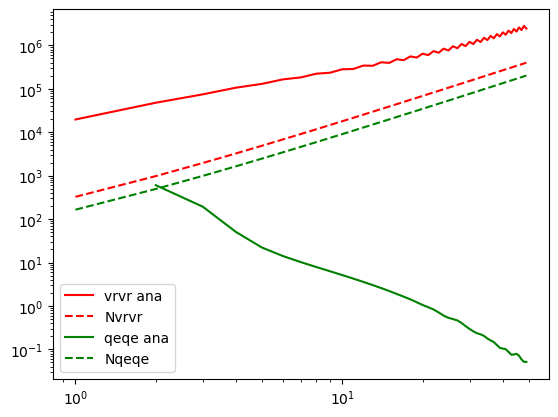

In [153]:
bin_num = 3
llow, lhigh = 1, 50

factor = (ls*(ls+1)/(2*pi))*conf.T_CMB**2

# plt.plot(L, CLgg[:, bin_num, bin_num], label='gg')
# plt.plot(ls[llow:lhigh], factor[llow:lhigh]*Clvrvr[:, bin_num, bin_num][llow:lhigh], label='vrvr')
plt.plot(ls[llow:lhigh], factor[llow:lhigh]*Clvrvr_ana[bin_num, :][llow:lhigh], 'r', label='vrvr ana')
plt.plot(ls[llow:lhigh], factor[llow:lhigh]*(np.ones_like(ls)*ClN_RDF[bin_num])[llow:lhigh], 'r--', label='Nvrvr')


plt.plot(ls[2:lhigh], factor[2:lhigh]*Clqeqe_ana[bin_num, :][2:lhigh], 'g', label='qeqe ana')

plt.plot(ls[llow:lhigh], factor[llow:lhigh]*(np.ones_like(ls)*ClN_RQF_E[bin_num])[llow:lhigh], 'g--', label='Nqeqe')
plt.xscale('log')
plt.yscale('log')
plt.legend()

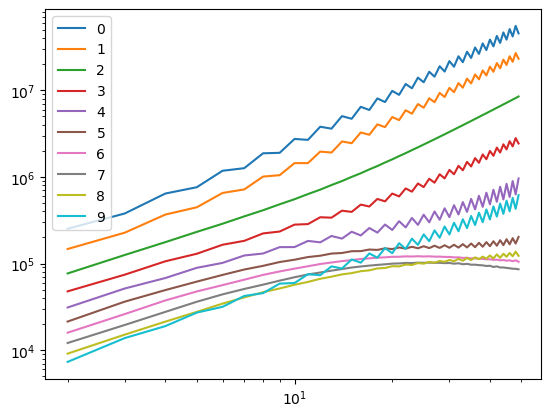

In [149]:
for bin_num in range(conf.N_bins):
    plt.plot(ls[2:lhigh], factor[2:lhigh]*Clvrvr_ana[bin_num, :][2:lhigh], label=f'{bin_num}')
plt.xscale('log')
plt.yscale('log')
plt.legend()

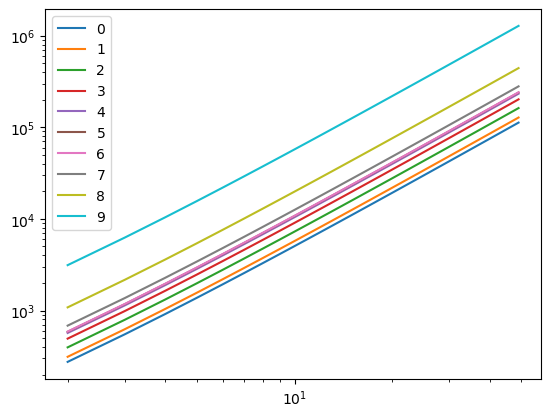

In [150]:
for bin_num in range(conf.N_bins):
    plt.plot(ls[2:lhigh], factor[2:lhigh]*(np.ones_like(ls)*ClN_RQF_E[bin_num])[2:lhigh], label=f'{bin_num}')
plt.xscale('log')
plt.yscale('log')
plt.legend()

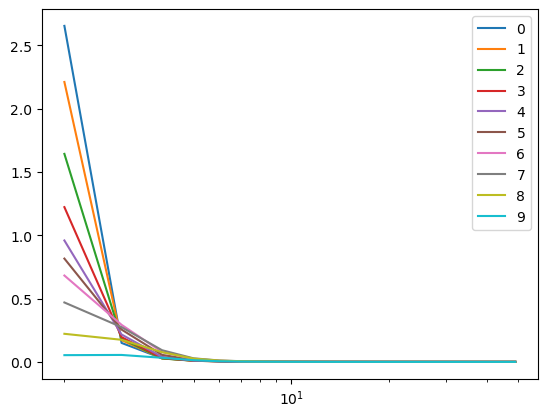

In [155]:
for bin_num in range(conf.N_bins):
    plt.plot(ls[2:lhigh], Clqeqe_ana[bin_num, :][2:lhigh]/(np.ones_like(ls)*ClN_RQF_E[bin_num])[2:lhigh], label=f'{bin_num}')
plt.xscale('log')
plt.legend()